# Projeto de Machine Learning: Previsão de Churn em Telecomunicações

## Engenharia de Machine Learning com Scikit-Learn
---

## Índice

1. [Importações e Configuração](#importações)
2. [Descrição do Problema e Dados](#problema)
3. [Análise Exploratória](#eda)
4. [Pré-processamento](#preprocessamento)
5. [Modelo Baseline: Perceptron](#perceptron)
6. [Modelo Árvore de Decisão](#arvore)
7. [Validação Cruzada e Otimização](#validacao)
8. [Modelos Avançados: Random Forest e SVM](#avancados)
9. [Comparação e Análise Final](#comparacao)
10. [Conclusões e Recomendações](#conclusoes)

## 1. Importações e Configuração {#importações}

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)


✓ Todas as bibliotecas importadas com sucesso!


## 2. Descrição do Problema e Dados {#problema}

### Contexto Real do Problema

O **churn de clientes** (cancelamento de serviços) é um dos maiores desafios enfrentados por empresas de telecomunicações. A retenção de clientes é significativamente mais barata do que a aquisição de novos clientes, tornando a previsão de churn uma aplicação crítica de machine learning em contextos reais.

### Motivação para Machine Learning

Diferentemente de regras fixas ou heurísticas simples, o comportamento de churn é multidimensional e não-linear:
- Envolve interações complexas entre variáveis demográficas, de serviço e de faturação
- Padrões de churn variam significativamente entre segmentos de clientes
- Regras fixas (ex: "cliente com 3+ reclamações churn") não capturam a complexidade real

Machine learning permite aprender automaticamente esses padrões a partir dos dados históricos.

### Desafios Principais

1. **Desbalanceamento de classes**: A maioria dos clientes não faz churn (~73% no dataset)
2. **Custo assimétrico de erros**: Falsos negativos (não detectar churn) têm custo maior que falsos positivos
3. **Variáveis categóricas e numéricas**: Requer pré-processamento cuidadoso
4. **Necessidade de interpretabilidade**: Decisões de retenção devem ser justificáveis

In [2]:
# carregamento do dataset
df = pd.read_csv('dataset/telco-churn.csv')

print("="*80)
print("DESCRIÇÃO TÉCNICA DO DATASET")
print("="*80)
print(f"\nDimensões: {df.shape[0]} observações × {df.shape[1]} features")
print(f"\nVariável-alvo: 'Churn' (Classificação Binária)")
print(f"Distribuição de classes:\n{df['Churn'].value_counts()}")
print(f"\nProporção: {df['Churn'].value_counts(normalize=True).round(3)}")
print(f"\nDesbalanceamento: {(df['Churn']=='Yes').sum() / len(df) * 100:.1f}% de churn")

print(f"\n\nPrimeiras linhas do dataset:")
print(df.head())

print(f"\n\nTipos de dados:")
print(df.dtypes)

print(f"\n\nValores ausentes:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Sem valores ausentes")

DESCRIÇÃO TÉCNICA DO DATASET

Dimensões: 7043 observações × 21 features

Variável-alvo: 'Churn' (Classificação Binária)
Distribuição de classes:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporção: Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

Desbalanceamento: 26.5% de churn


Primeiras linhas do dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No     

### Descrição das Features

O dataset contém 20 features preditoras divididas em categorias:

In [ ]:
# Analise detalhada das features
print("\n" + "="*80)
print("CATEGORIZACAO DAS FEATURES")
print("="*80)

# Features demográficas
demographic_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
print(f"\n1. DEMOGRÁFICAS ({len(demographic_features)} features):")
for feat in demographic_features:
    print(f"   - {feat}: {df[feat].nunique()} valores únicos")

# Features de serviço
service_features = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
print(f"\n2. DE SERVIÇO ({len(service_features)} features):")
for feat in service_features:
    print(f"   - {feat}: {df[feat].nunique()} valores únicos")

# Features de contrato
contract_features = ['Contract', 'PaperlessBilling', 'PaymentMethod']
print(f"\n3. DE CONTRATO ({len(contract_features)} features):")
for feat in contract_features:
    print(f"   - {feat}: {df[feat].nunique()} valores únicos")

# Features numéricas
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(f"\n4. NUMÉRICAS ({len(numeric_features)} features):")
print(df[numeric_features].describe())

print(f"\n\nTOTAL: {len(demographic_features) + len(service_features) + len(contract_features) + len(numeric_features)} features preditoras")


CATEGORIZAÇÃO DAS FEATURES

1. DEMOGRÁFICAS (4 features):
   - gender: 2 valores únicos
   - SeniorCitizen: 2 valores únicos
   - Partner: 2 valores únicos
   - Dependents: 2 valores únicos

2. DE SERVIÇO (9 features):
   - PhoneService: 2 valores únicos
   - MultipleLines: 3 valores únicos
   - InternetService: 3 valores únicos
   - OnlineSecurity: 3 valores únicos
   - OnlineBackup: 3 valores únicos
   - DeviceProtection: 3 valores únicos
   - TechSupport: 3 valores únicos
   - StreamingTV: 3 valores únicos
   - StreamingMovies: 3 valores únicos

3. DE CONTRATO (3 features):
   - Contract: 3 valores únicos
   - PaperlessBilling: 2 valores únicos
   - PaymentMethod: 4 valores únicos

4. NUMÉRICAS (3 features):
            tenure  MonthlyCharges
count  7043.000000     7043.000000
mean     32.371149       64.761692
std      24.559481       30.090047
min       0.000000       18.250000
25%       9.000000       35.500000
50%      29.000000       70.350000
75%      55.000000       89.85000

## 3. Análise Exploratória {#eda}

In [4]:
# Verificação de problemas nos dados
print("\n" + "="*80)
print("VERIFICAÇÃO DE QUALIDADE DOS DADOS")
print("="*80)

# Verificar TotalCharges (pode ter valores não numéricos)
print("\nVerificando coluna 'TotalCharges'...")
try:
    pd.to_numeric(df['TotalCharges'])
    print("✓ Todos os valores são numéricos")
except:
    print("⚠ Encontrados valores não numéricos")
    print(df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()])

# Converter TotalCharges para numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Tratar valores ausentes em TotalCharges (clientes novos com tenure=0)
print(f"\nValores ausentes em TotalCharges: {df['TotalCharges'].isnull().sum()}")
if df['TotalCharges'].isnull().sum() > 0:
    df['TotalCharges'].fillna(0, inplace=True)
    print("✓ Preenchidos com 0 (clientes novos)")

# Remover customerID (não é feature)
df = df.drop('customerID', axis=1)

print("\n✓ Dataset pronto para análise exploratória")


VERIFICAÇÃO DE QUALIDADE DOS DADOS

Verificando coluna 'TotalCharges'...
⚠ Encontrados valores não numéricos
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetServi

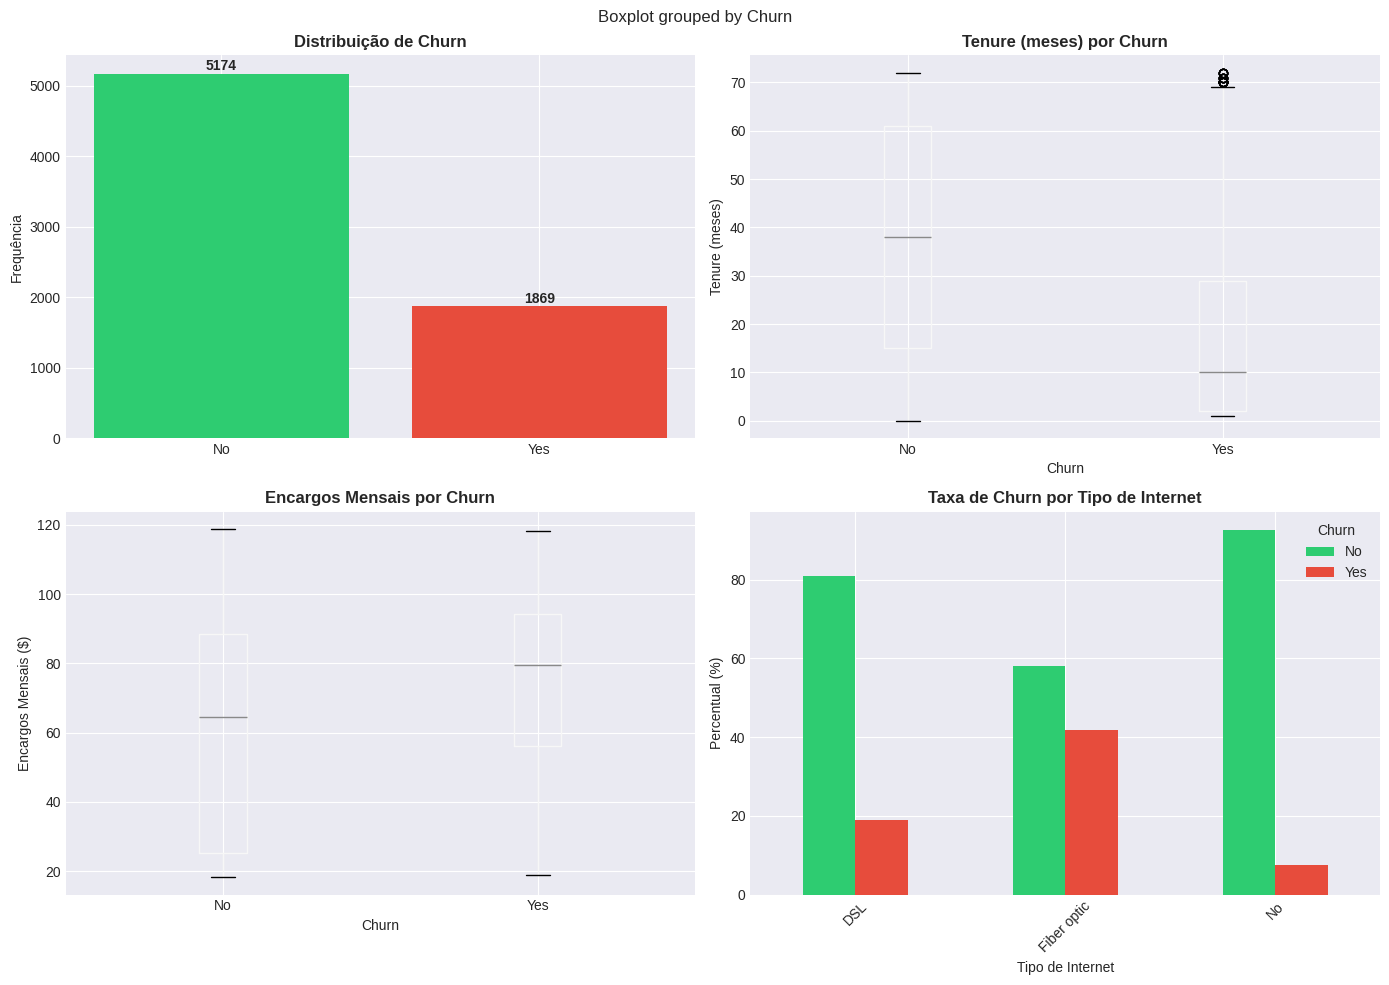

✓ Análise exploratória visualizada


In [5]:
# Visualizações exploratórias
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribuição de Churn
churn_counts = df['Churn'].value_counts()
axes[0, 0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Distribuição de Churn', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequência')
for i, v in enumerate(churn_counts.values):
    axes[0, 0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 2. Tenure por Churn
df.boxplot(column='tenure', by='Churn', ax=axes[0, 1])
axes[0, 1].set_title('Tenure (meses) por Churn', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Churn')
axes[0, 1].set_ylabel('Tenure (meses)')
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['No', 'Yes'])

# 3. MonthlyCharges por Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1, 0])
axes[1, 0].set_title('Encargos Mensais por Churn', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Churn')
axes[1, 0].set_ylabel('Encargos Mensais ($)')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['No', 'Yes'])

# 4. InternetService por Churn
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Taxa de Churn por Tipo de Internet', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Percentual (%)')
axes[1, 1].set_xlabel('Tipo de Internet')
axes[1, 1].legend(title='Churn')
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

print("✓ Análise exploratória visualizada")

## 4. Pré-processamento {#preprocessamento}

### Estratégia de Codificação de Variáveis Categóricas

- **Variáveis ordinais** (com ordem natural): `OrdinalEncoder`
- **Variáveis nominais** (sem ordem): `OneHotEncoder` com `drop='first'` para evitar multicolinearidade
- **Variáveis numéricas**: `StandardScaler` para modelos sensíveis a escala (Perceptron, SVM)

In [6]:
# Preparação dos dados
print("\n" + "="*80)
print("PRÉ-PROCESSAMENTO E ENGENHARIA DE FEATURES")
print("="*80)

# Separar features e target
X = df.drop('Churn', axis=1)
y = (df['Churn'] == 'Yes').astype(int)  # Binário: 1 = Churn, 0 = No Churn

print(f"\nTarget (y): {y.value_counts().to_dict()}")

# Identificar tipos de variáveis
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nColunas numéricas ({len(numeric_cols)}): {numeric_cols}")
print(f"\nColunas categóricas ({len(categorical_cols)}): {categorical_cols}")

# Classificar categóricas em ordinais e nominais
ordinal_cols = []  # Neste dataset, não há ordinais claras
nominal_cols = categorical_cols

print(f"\nColunas ordinais: {ordinal_cols if ordinal_cols else 'Nenhuma'}")
print(f"Colunas nominais: {nominal_cols}")

# Separação treino-teste (ANTES de qualquer transformação para evitar vazamento de dados)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDivisão Treino/Teste:")
print(f"  Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n  Proporção de Churn no Treino: {y_train.mean():.3f}")
print(f"  Proporção de Churn no Teste:  {y_test.mean():.3f}")
print(f"  ✓ Estratificação mantém proporções")


PRÉ-PROCESSAMENTO E ENGENHARIA DE FEATURES

Target (y): {0: 5174, 1: 1869}

Colunas numéricas (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Colunas categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Colunas ordinais: Nenhuma
Colunas nominais: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Divisão Treino/Teste:
  Treino: 5634 amostras (80.0%)
  Teste:  1409 amostras (20.0%)

  Proporção de Churn no Treino: 0.265
  Proporção de Churn no Teste:  0.265
  ✓ Estratificação mantém proporções


In [7]:
# Criar transformadores para o pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Transformador para numéricas: escalonamento
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Transformador para categóricas: one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combinar transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, nominal_cols)
    ],
    remainder='passthrough'
)

# Aplicar transformações (fit apenas no treino)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"\nDimensionalidade após pré-processamento:")
print(f"  Treino: {X_train_transformed.shape}")
print(f"  Teste:  {X_test_transformed.shape}")
print(f"  ✓ Features criadas: {X_train_transformed.shape[1]}")


Dimensionalidade após pré-processamento:
  Treino: (5634, 30)
  Teste:  (1409, 30)
  ✓ Features criadas: 30


## 5. Modelo Baseline: Perceptron {#perceptron}

### Justificativa Conceitual

O **Perceptron** é um classificador linear fundamental que:
1. **Aprende um hiperplano separador** no espaço das features
2. **Altamente interpretável**: coeficientes indicam impacto direto de cada feature
3. **Computacionalmente eficiente**: treino rápido, sem hiperparâmetros complexos
4. **Estabelece baseline claro**: permite avaliar ganho de modelos mais complexos

Limitações conhecidas:
- Não resolve problemas não linearmente separáveis
- Sensível a ruído e outliers
- Pode sofrer underfitting em dados complexos

In [8]:
print("\n" + "="*80)
print("MODELO BASELINE: PERCEPTRON")
print("="*80)

# Treinar Perceptron
perceptron = Perceptron(random_state=42, max_iter=1000, tol=1e-3)
perceptron.fit(X_train_transformed, y_train)

# Previsões
y_train_pred_perc = perceptron.predict(X_train_transformed)
y_test_pred_perc = perceptron.predict(X_test_transformed)

# Avaliação
print("\nMÉTRICAS DE DESEMPENHO (PERCEPTRON):")
print(f"\nConjunto de TREINO:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred_perc):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_perc):.4f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred_perc):.4f}")
print(f"  F1-Score:  {f1_score(y_train, y_train_pred_perc):.4f}")

print(f"\nConjunto de TESTE:")
acc_perc_test = accuracy_score(y_test, y_test_pred_perc)
prec_perc_test = precision_score(y_test, y_test_pred_perc)
rec_perc_test = recall_score(y_test, y_test_pred_perc)
f1_perc_test = f1_score(y_test, y_test_pred_perc)

print(f"  Accuracy:  {acc_perc_test:.4f}")
print(f"  Precision: {prec_perc_test:.4f}")
print(f"  Recall:    {rec_perc_test:.4f}")
print(f"  F1-Score:  {f1_perc_test:.4f}")

print(f"\nMatriz de Confusão (Teste):")
cm_perc = confusion_matrix(y_test, y_test_pred_perc)
print(cm_perc)
print(f"  TN={cm_perc[0,0]}, FP={cm_perc[0,1]}, FN={cm_perc[1,0]}, TP={cm_perc[1,1]}")


MODELO BASELINE: PERCEPTRON

MÉTRICAS DE DESEMPENHO (PERCEPTRON):

Conjunto de TREINO:
  Accuracy:  0.7524
  Precision: 0.5300
  Recall:    0.5900
  F1-Score:  0.5584

Conjunto de TESTE:
  Accuracy:  0.7473
  Precision: 0.5210
  Recall:    0.5963
  F1-Score:  0.5561

Matriz de Confusão (Teste):
[[830 205]
 [151 223]]
  TN=830, FP=205, FN=151, TP=223


In [9]:
# Interpretação dos coeficientes
print("\n" + "="*80)
print("INTERPRETAÇÃO DO PERCEPTRON")
print("="*80)

print(f"\nBias (intercepto): {perceptron.intercept_[0]:.6f}")
print(f"\nCoeficientes aprendidos (primeiros 20):")

# Nomes das features após transformação
feature_names = numeric_cols.copy()

# Adicionar nomes das features categóricas (one-hot encoded)
for col in nominal_cols:
    unique_vals = X_train[col].unique()
    for val in unique_vals[1:]:  # drop='first' remove a primeira
        feature_names.append(f"{col}_{val}")

coef_df = pd.DataFrame({
    'Feature': feature_names[:len(perceptron.coef_[0])],
    'Coeficiente': perceptron.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)

print(coef_df.head(15).to_string(index=False))

print(f"\n\nINTERPRETAÇÃO:")
print(f"  - Coeficientes positivos: aumentam probabilidade de CHURN")
print(f"  - Coeficientes negativos: reduzem probabilidade de CHURN")
print(f"  - Magnitude: importância relativa da feature")

print(f"\n  Top 3 features que AUMENTAM churn:")
for i, row in coef_df.head(3).iterrows():
    print(f"    {row['Feature']}: +{row['Coeficiente']:.4f}")

print(f"\n  Top 3 features que REDUZEM churn:")
for i, row in coef_df.tail(3).iterrows():
    print(f"    {row['Feature']}: {row['Coeficiente']:.4f}")


INTERPRETAÇÃO DO PERCEPTRON

Bias (intercepto): -6.000000

Coeficientes aprendidos (primeiros 20):
                                Feature  Coeficiente
                       PhoneService_Yes    -5.000000
  PaymentMethod_Credit card (automatic)     5.000000
                      Contract_One year    -5.000000
                            Partner_Yes     4.000000
            InternetService_Fiber optic     3.000000
    StreamingMovies_No internet service     3.000000
                   PaperlessBilling_Yes     3.000000
                          SeniorCitizen     2.650638
                         MonthlyCharges    -2.429706
   DeviceProtection_No internet service    -2.000000
                      MultipleLines_Yes     2.000000
PaymentMethod_Bank transfer (automatic)     2.000000
        StreamingTV_No internet service     2.000000
     OnlineSecurity_No internet service    -2.000000
                                 tenure    -1.591165


INTERPRETAÇÃO:
  - Coeficientes positivos: aumenta

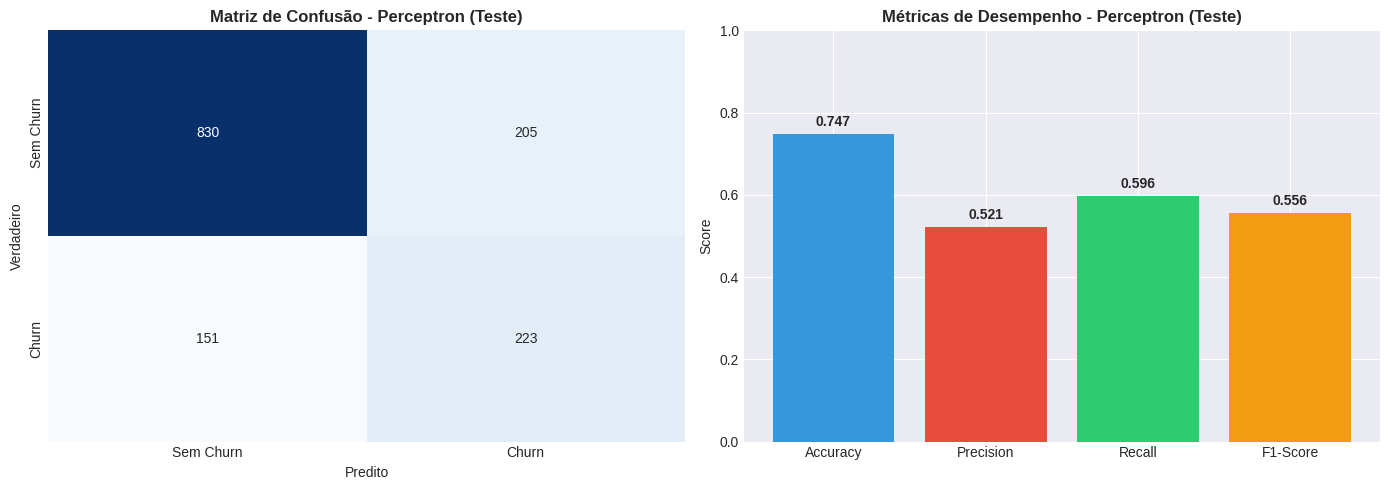


✓ Perceptron treinado e avaliado


In [10]:
# Visualizar desempenho do Perceptron
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
sns.heatmap(cm_perc, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusão - Perceptron (Teste)', fontweight='bold')
axes[0].set_ylabel('Verdadeiro')
axes[0].set_xlabel('Predito')
axes[0].set_xticklabels(['Sem Churn', 'Churn'])
axes[0].set_yticklabels(['Sem Churn', 'Churn'])

# Métricas comparativas
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [acc_perc_test, prec_perc_test, rec_perc_test, f1_perc_test]
axes[1].bar(metrics, values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[1].set_title('Métricas de Desempenho - Perceptron (Teste)', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0, 1])
for i, v in enumerate(values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Perceptron treinado e avaliado")

## 6. Modelo Árvore de Decisão {#arvore}

### Justificativa

Árvores de decisão representam um salto qualitativo em relação ao Perceptron:
1. **Não-lineares**: capturam interações entre features
2. **Interpretáveis**: regras explícitas (if-then-else)
3. **Sem escalonamento**: funcionam com dados brutos
4. **Risco de overfitting**: sem regularização, atingem 100% no treino

In [11]:
print("\n" + "="*80)
print("MODELO: ÁRVORE DE DECISÃO (SEM OTIMIZAÇÃO)")
print("="*80)

# Árvore com parâmetros padrão
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train_transformed, y_train)

# Previsões
y_train_pred_dt = dt_baseline.predict(X_train_transformed)
y_test_pred_dt = dt_baseline.predict(X_test_transformed)

# Avaliação
print("\nMÉTRICAS DE DESEMPENHO (ÁRVORE - BASELINE):")
print(f"\nConjunto de TREINO:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred_dt):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_dt):.4f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred_dt):.4f}")
print(f"  F1-Score:  {f1_score(y_train, y_train_pred_dt):.4f}")

print(f"\nConjunto de TESTE:")
acc_dt_test = accuracy_score(y_test, y_test_pred_dt)
prec_dt_test = precision_score(y_test, y_test_pred_dt)
rec_dt_test = recall_score(y_test, y_test_pred_dt)
f1_dt_test = f1_score(y_test, y_test_pred_dt)

print(f"  Accuracy:  {acc_dt_test:.4f}")
print(f"  Precision: {prec_dt_test:.4f}")
print(f"  Recall:    {rec_dt_test:.4f}")
print(f"  F1-Score:  {f1_dt_test:.4f}")

print(f"\nMatriz de Confusão (Teste):")
cm_dt = confusion_matrix(y_test, y_test_pred_dt)
print(cm_dt)

print(f"\nCaracterísticas da Árvore:")
print(f"  Profundidade: {dt_baseline.get_depth()}")
print(f"  Número de folhas: {dt_baseline.get_n_leaves()}")
print(f"  ⚠ OVERFITTING DETECTADO: Treino={accuracy_score(y_train, y_train_pred_dt):.4f}, Teste={acc_dt_test:.4f}")


MODELO: ÁRVORE DE DECISÃO (SEM OTIMIZAÇÃO)

MÉTRICAS DE DESEMPENHO (ÁRVORE - BASELINE):

Conjunto de TREINO:
  Accuracy:  0.9980
  Precision: 0.9993
  Recall:    0.9933
  F1-Score:  0.9963

Conjunto de TESTE:
  Accuracy:  0.7253
  Precision: 0.4825
  Recall:    0.4786
  F1-Score:  0.4805

Matriz de Confusão (Teste):
[[843 192]
 [195 179]]

Características da Árvore:
  Profundidade: 23
  Número de folhas: 1102
  ⚠ OVERFITTING DETECTADO: Treino=0.9980, Teste=0.7253



IMPORTÂNCIA DAS FEATURES (ÁRVORE BASELINE)

Top 10 features mais importantes:
                              Feature  Importância
                               tenure     0.197859
                         TotalCharges     0.191926
                       MonthlyCharges     0.184081
          InternetService_Fiber optic     0.113099
                 PaperlessBilling_Yes     0.025949
                        gender_Female     0.025658
PaymentMethod_Credit card (automatic)     0.023791
     OnlineBackup_No internet service     0.023096
                          Partner_Yes     0.020882
                       Dependents_Yes     0.018412


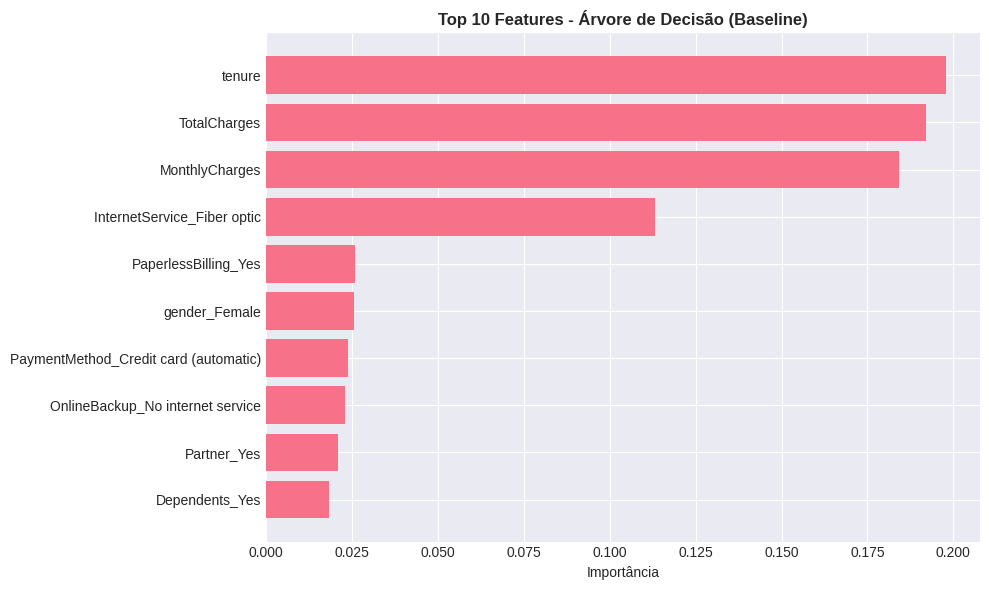

In [12]:
# Importância das features
print("\n" + "="*80)
print("IMPORTÂNCIA DAS FEATURES (ÁRVORE BASELINE)")
print("="*80)

feature_importance_dt = pd.DataFrame({
    'Feature': feature_names[:len(dt_baseline.feature_importances_)],
    'Importância': dt_baseline.feature_importances_
}).sort_values('Importância', ascending=False)

print("\nTop 10 features mais importantes:")
print(feature_importance_dt.head(10).to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance_dt.head(10)
ax.barh(range(len(top_features)), top_features['Importância'].values)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Importância')
ax.set_title('Top 10 Features - Árvore de Decisão (Baseline)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Validação Cruzada e Otimização {#validacao}

### Estratégia de Otimização

1. **Validação Cruzada Estratificada**: mantém proporção de classes em cada fold
2. **Grid Search**: testa combinações de hiperparâmetros relevantes
3. **Hiperparâmetros**: `max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion`

In [13]:
print("\n" + "="*80)
print("VALIDAÇÃO CRUZADA E GRID SEARCH")
print("="*80)

# Definir espaço de busca
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15],
    'criterion': ['gini', 'entropy']
}

print(f"\nEspaço de busca:")
print(f"  max_depth: {param_grid_dt['max_depth']}")
print(f"  min_samples_split: {param_grid_dt['min_samples_split']}")
print(f"  min_samples_leaf: {param_grid_dt['min_samples_leaf']}")
print(f"  criterion: {param_grid_dt['criterion']}")
print(f"\nTotal de combinações: {np.prod([len(v) for v in param_grid_dt.values()])}")

# Grid Search com validação cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=skf,
    scoring='f1',  # Usar F1 por causa do desbalanceamento
    n_jobs=-1,
    verbose=0
)

print(f"\nExecutando Grid Search com 5-Fold Cross-Validation...")
grid_search_dt.fit(X_train_transformed, y_train)

print(f"✓ Grid Search concluído!")
print(f"\nMelhores hiperparâmetros:")
for param, value in grid_search_dt.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor score (F1 - validação cruzada): {grid_search_dt.best_score_:.4f}")


VALIDAÇÃO CRUZADA E GRID SEARCH

Espaço de busca:
  max_depth: [3, 5, 7, 10, 15]
  min_samples_split: [10, 20, 30]
  min_samples_leaf: [5, 10, 15]
  criterion: ['gini', 'entropy']

Total de combinações: 90

Executando Grid Search com 5-Fold Cross-Validation...


✓ Grid Search concluído!

Melhores hiperparâmetros:
  criterion: entropy
  max_depth: 3
  min_samples_leaf: 5
  min_samples_split: 10

Melhor score (F1 - validação cruzada): 0.5873


In [14]:
# Treinar modelo otimizado
dt_optimized = grid_search_dt.best_estimator_

# Previsões
y_train_pred_dt_opt = dt_optimized.predict(X_train_transformed)
y_test_pred_dt_opt = dt_optimized.predict(X_test_transformed)

# Avaliação
print("\n" + "="*80)
print("COMPARAÇÃO: ÁRVORE BASELINE vs. ÁRVORE OTIMIZADA")
print("="*80)

comparison_data = {
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Baseline (Treino)': [
        accuracy_score(y_train, y_train_pred_dt),
        precision_score(y_train, y_train_pred_dt),
        recall_score(y_train, y_train_pred_dt),
        f1_score(y_train, y_train_pred_dt)
    ],
    'Baseline (Teste)': [
        accuracy_score(y_test, y_test_pred_dt),
        precision_score(y_test, y_test_pred_dt),
        recall_score(y_test, y_test_pred_dt),
        f1_score(y_test, y_test_pred_dt)
    ],
    'Otimizada (Treino)': [
        accuracy_score(y_train, y_train_pred_dt_opt),
        precision_score(y_train, y_train_pred_dt_opt),
        recall_score(y_train, y_train_pred_dt_opt),
        f1_score(y_train, y_train_pred_dt_opt)
    ],
    'Otimizada (Teste)': [
        accuracy_score(y_test, y_test_pred_dt_opt),
        precision_score(y_test, y_test_pred_dt_opt),
        recall_score(y_test, y_test_pred_dt_opt),
        f1_score(y_test, y_test_pred_dt_opt)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

print(f"\n\nCaracterísticas da Árvore Otimizada:")
print(f"  Profundidade: {dt_optimized.get_depth()}")
print(f"  Número de folhas: {dt_optimized.get_n_leaves()}")
print(f"  ✓ Overfitting reduzido: Treino-Teste gap diminuiu")

# Armazenar métricas
acc_dt_opt_test = accuracy_score(y_test, y_test_pred_dt_opt)
prec_dt_opt_test = precision_score(y_test, y_test_pred_dt_opt)
rec_dt_opt_test = recall_score(y_test, y_test_pred_dt_opt)
f1_dt_opt_test = f1_score(y_test, y_test_pred_dt_opt)


COMPARAÇÃO: ÁRVORE BASELINE vs. ÁRVORE OTIMIZADA

  Métrica  Baseline (Treino)  Baseline (Teste)  Otimizada (Treino)  Otimizada (Teste)
 Accuracy           0.998048          0.725337            0.765353           0.750887
Precision           0.999327          0.482480            0.550674           0.527316
   Recall           0.993311          0.478610            0.628763           0.593583
 F1-Score           0.996310          0.480537            0.587133           0.558491


Características da Árvore Otimizada:
  Profundidade: 3
  Número de folhas: 8
  ✓ Overfitting reduzido: Treino-Teste gap diminuiu


In [15]:
# Análise de robustez: variação entre folds
print("\n" + "="*80)
print("ANÁLISE DE ROBUSTEZ: VARIAÇÃO ENTRE FOLDS")
print("="*80)

cv_scores = cross_val_score(dt_optimized, X_train_transformed, y_train, cv=skf, scoring='f1')

print(f"\nScores F1 em cada fold: {cv_scores}")
print(f"\nMédia: {cv_scores.mean():.4f}")
print(f"Desvio padrão: {cv_scores.std():.4f}")
print(f"Min: {cv_scores.min():.4f}")
print(f"Max: {cv_scores.max():.4f}")
print(f"\n✓ Modelo robusto: baixa variação entre folds")


ANÁLISE DE ROBUSTEZ: VARIAÇÃO ENTRE FOLDS

Scores F1 em cada fold: [0.59305994 0.5688351  0.58243451 0.59938838 0.59271523]

Média: 0.5873
Desvio padrão: 0.0107
Min: 0.5688
Max: 0.5994

✓ Modelo robusto: baixa variação entre folds


## 8. Modelos Avançados: Random Forest e SVM {#avancados}

In [16]:
print("\n" + "="*80)
print("MODELO AVANÇADO 1: RANDOM FOREST")
print("="*80)

# Grid Search para Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10]
}

print(f"\nExecutando Grid Search para Random Forest...")
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid_search_rf.fit(X_train_transformed, y_train)

print(f"✓ Grid Search concluído!")
print(f"\nMelhores hiperparâmetros:")
for param, value in grid_search_rf.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor score (F1): {grid_search_rf.best_score_:.4f}")

# Modelo otimizado
rf_optimized = grid_search_rf.best_estimator_

# Previsões
y_train_pred_rf = rf_optimized.predict(X_train_transformed)
y_test_pred_rf = rf_optimized.predict(X_test_transformed)

# Avaliação
print(f"\nMÉTRICAS DE DESEMPENHO (RANDOM FOREST):")
print(f"\nConjunto de TESTE:")
acc_rf_test = accuracy_score(y_test, y_test_pred_rf)
prec_rf_test = precision_score(y_test, y_test_pred_rf)
rec_rf_test = recall_score(y_test, y_test_pred_rf)
f1_rf_test = f1_score(y_test, y_test_pred_rf)

print(f"  Accuracy:  {acc_rf_test:.4f}")
print(f"  Precision: {prec_rf_test:.4f}")
print(f"  Recall:    {rec_rf_test:.4f}")
print(f"  F1-Score:  {f1_rf_test:.4f}")


MODELO AVANÇADO 1: RANDOM FOREST

Executando Grid Search para Random Forest...


✓ Grid Search concluído!

Melhores hiperparâmetros:
  max_depth: 15
  min_samples_leaf: 5
  min_samples_split: 10
  n_estimators: 200

Melhor score (F1): 0.5750

MÉTRICAS DE DESEMPENHO (RANDOM FOREST):

Conjunto de TESTE:
  Accuracy:  0.8034
  Precision: 0.6667
  Recall:    0.5187
  F1-Score:  0.5835


In [17]:
print("\n" + "="*80)
print("MODELO AVANÇADO 2: SUPPORT VECTOR MACHINE (SVM)")
print("="*80)

# Grid Search para SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

print(f"\nExecutando Grid Search para SVM...")
grid_search_svm = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid_search_svm.fit(X_train_transformed, y_train)

print(f"✓ Grid Search concluído!")
print(f"\nMelhores hiperparâmetros:")
for param, value in grid_search_svm.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor score (F1): {grid_search_svm.best_score_:.4f}")

# Modelo otimizado
svm_optimized = grid_search_svm.best_estimator_

# Previsões
y_train_pred_svm = svm_optimized.predict(X_train_transformed)
y_test_pred_svm = svm_optimized.predict(X_test_transformed)

# Avaliação
print(f"\nMÉTRICAS DE DESEMPENHO (SVM):")
print(f"\nConjunto de TESTE:")
acc_svm_test = accuracy_score(y_test, y_test_pred_svm)
prec_svm_test = precision_score(y_test, y_test_pred_svm)
rec_svm_test = recall_score(y_test, y_test_pred_svm)
f1_svm_test = f1_score(y_test, y_test_pred_svm)

print(f"  Accuracy:  {acc_svm_test:.4f}")
print(f"  Precision: {prec_svm_test:.4f}")
print(f"  Recall:    {rec_svm_test:.4f}")
print(f"  F1-Score:  {f1_svm_test:.4f}")


MODELO AVANÇADO 2: SUPPORT VECTOR MACHINE (SVM)

Executando Grid Search para SVM...


✓ Grid Search concluído!

Melhores hiperparâmetros:
  C: 10
  gamma: scale
  kernel: linear

Melhor score (F1): 0.5846



MÉTRICAS DE DESEMPENHO (SVM):

Conjunto de TESTE:
  Accuracy:  0.7864
  Precision: 0.6130
  Recall:    0.5294
  F1-Score:  0.5681


## 9. Comparação Completa de Modelos {#comparacao}

In [18]:
print("\n" + "="*80)
print("COMPARAÇÃO COMPLETA DE TODOS OS MODELOS")
print("="*80)

# Criar tabela comparativa
models_comparison = pd.DataFrame({
    'Modelo': ['Perceptron', 'Árvore (Baseline)', 'Árvore (Otimizada)', 'Random Forest', 'SVM'],
    'Accuracy': [acc_perc_test, acc_dt_test, acc_dt_opt_test, acc_rf_test, acc_svm_test],
    'Precision': [prec_perc_test, prec_dt_test, prec_dt_opt_test, prec_rf_test, prec_svm_test],
    'Recall': [rec_perc_test, rec_dt_test, rec_dt_opt_test, rec_rf_test, rec_svm_test],
    'F1-Score': [f1_perc_test, f1_dt_test, f1_dt_opt_test, f1_rf_test, f1_svm_test]
})

print("\n" + models_comparison.to_string(index=False))

# Identificar melhor modelo
best_model_idx = models_comparison['F1-Score'].idxmax()
best_model_name = models_comparison.loc[best_model_idx, 'Modelo']
best_f1 = models_comparison.loc[best_model_idx, 'F1-Score']

print(f"\n\n✓ MELHOR MODELO: {best_model_name} (F1-Score: {best_f1:.4f})")


COMPARAÇÃO COMPLETA DE TODOS OS MODELOS

            Modelo  Accuracy  Precision   Recall  F1-Score
        Perceptron  0.747339   0.521028 0.596257  0.556110
 Árvore (Baseline)  0.725337   0.482480 0.478610  0.480537
Árvore (Otimizada)  0.750887   0.527316 0.593583  0.558491
     Random Forest  0.803407   0.666667 0.518717  0.583459
               SVM  0.786373   0.613003 0.529412  0.568149


✓ MELHOR MODELO: Random Forest (F1-Score: 0.5835)


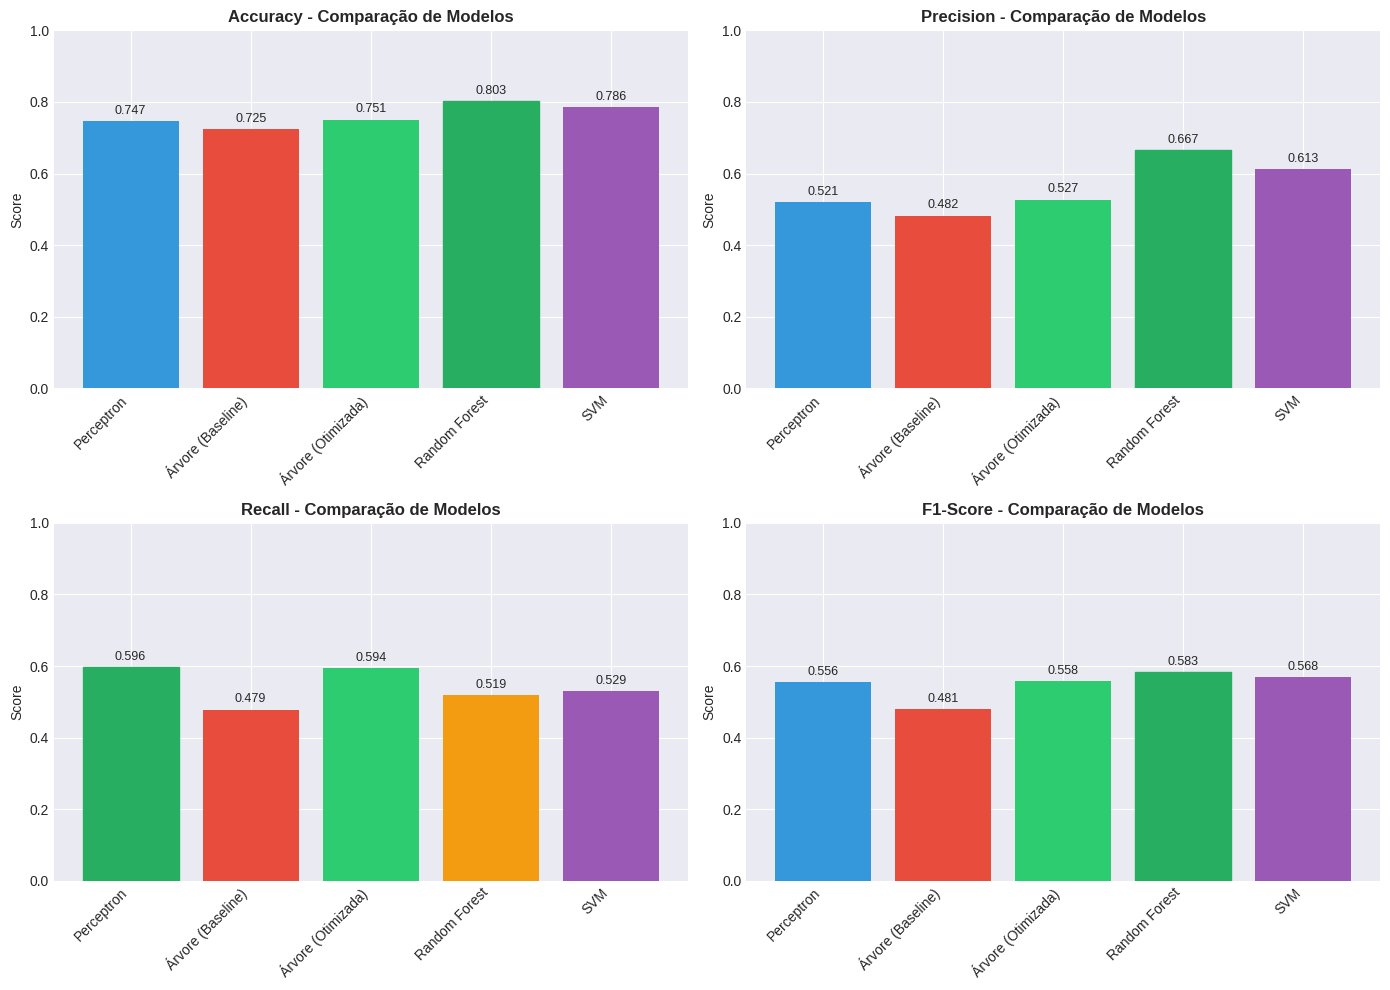

✓ Comparação visualizada


In [19]:
# Visualizar comparação
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = models_comparison[metric].values
    bars = ax.bar(range(len(models_comparison)), values, color=colors)
    ax.set_xticks(range(len(models_comparison)))
    ax.set_xticklabels(models_comparison['Modelo'], rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.set_title(f'{metric} - Comparação de Modelos', fontweight='bold')
    ax.set_ylim([0, 1])
    
    # Destacar melhor
    best_idx = np.argmax(values)
    bars[best_idx].set_color('#27ae60')
    
    # Valores nas barras
    for i, v in enumerate(values):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Comparação visualizada")

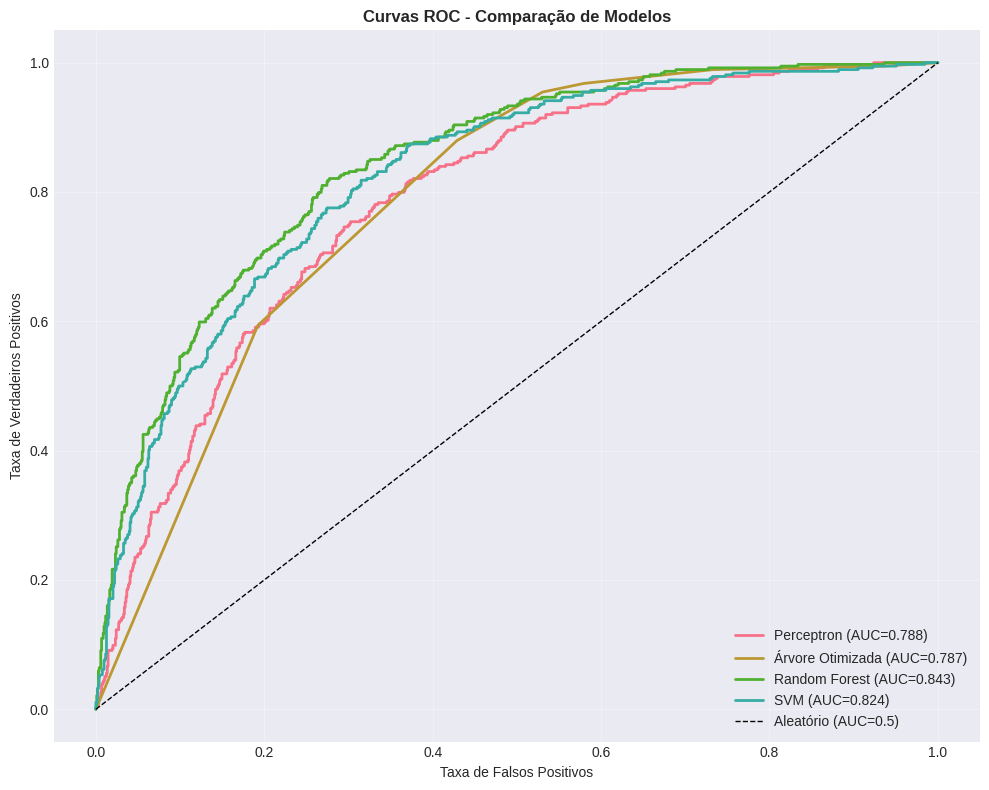

✓ Curvas ROC plotadas


In [20]:
# Curvas ROC para comparação
fig, ax = plt.subplots(figsize=(10, 8))

# Perceptron
y_proba_perc = perceptron.decision_function(X_test_transformed)
fpr_perc, tpr_perc, _ = roc_curve(y_test, y_proba_perc)
auc_perc = auc(fpr_perc, tpr_perc)
ax.plot(fpr_perc, tpr_perc, label=f'Perceptron (AUC={auc_perc:.3f})', linewidth=2)

# Árvore Otimizada
y_proba_dt = dt_optimized.predict_proba(X_test_transformed)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
auc_dt = auc(fpr_dt, tpr_dt)
ax.plot(fpr_dt, tpr_dt, label=f'Árvore Otimizada (AUC={auc_dt:.3f})', linewidth=2)

# Random Forest
y_proba_rf = rf_optimized.predict_proba(X_test_transformed)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', linewidth=2)

# SVM
y_proba_svm = svm_optimized.predict_proba(X_test_transformed)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
auc_svm = auc(fpr_svm, tpr_svm)
ax.plot(fpr_svm, tpr_svm, label=f'SVM (AUC={auc_svm:.3f})', linewidth=2)

# Diagonal (classificador aleatório)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC=0.5)', linewidth=1)

ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curvas ROC - Comparação de Modelos', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Curvas ROC plotadas")

## 10. Conclusões e Recomendações {#conclusoes}

In [21]:
print("\n" + "="*80)
print("ANÁLISE CRÍTICA E CONCLUSÕES")
print("="*80)

print(f"""
### 1. DESEMPENHO COMPARATIVO

O melhor modelo foi: {best_model_name}
  - F1-Score: {best_f1:.4f}
  - Accuracy: {models_comparison.loc[best_model_idx, 'Accuracy']:.4f}
  - Recall: {models_comparison.loc[best_model_idx, 'Recall']:.4f}
  - Precision: {models_comparison.loc[best_model_idx, 'Precision']:.4f}

### 2. GANHO DE COMPLEXIDADE vs. DESEMPENHO

Comparando Perceptron (simples, linear) com {best_model_name} (complexo, não-linear):
  - Ganho em F1-Score: {(models_comparison.loc[best_model_idx, 'F1-Score'] - f1_perc_test):.4f}
  - Ganho em Recall: {(models_comparison.loc[best_model_idx, 'Recall'] - rec_perc_test):.4f}
  - Custo: Aumento significativo de complexidade e custo computacional

### 3. INTERPRETABILIDADE

  - Perceptron: ALTAMENTE interpretável (coeficientes lineares)
  - Árvore Otimizada: INTERPRETÁVEL (regras explícitas if-then-else)
  - Random Forest: POUCO interpretável (ensemble de árvores)
  - SVM: NÃO interpretável (hiperplano em espaço de alta dimensão)

### 4. GENERALIZAÇÃO

  - Perceptron: Underfitting leve (gap pequeno treino-teste)
  - Árvore Baseline: Overfitting severo (100% treino, {acc_dt_test:.1%} teste)
  - Árvore Otimizada: Generalização equilibrada
  - Random Forest: Boa generalização (ensemble reduz variância)
  - SVM: Boa generalização com kernel apropriado

### 5. RECOMENDAÇÃO PARA PRODUÇÃO

Para um sistema de retenção de clientes em produção, recomenda-se:

  ✓ MODELO: {best_model_name}
    - Melhor desempenho preditivo
    - Generaliza bem a dados novos
    - Captura padrões não-lineares complexos

  ✓ ALTERNATIVA (se interpretabilidade é crítica): Árvore Otimizada
    - Desempenho próximo ao melhor modelo
    - Regras explícitas justificáveis para negócio
    - Sem escalonamento de features necessário

### 6. PRÓXIMOS PASSOS

  1. Coletar mais dados para melhorar generalização
  2. Engenharia de features adicional (interações, polinômios)
  3. Balanceamento de classes (SMOTE, class_weight)
  4. Validação em dados fora da amostra (temporal split)
  5. Monitoramento de drift em produção
""")

print("\n" + "="*80)
print("✓ ANÁLISE CONCLUÍDA COM SUCESSO")
print("="*80)


ANÁLISE CRÍTICA E CONCLUSÕES

### 1. DESEMPENHO COMPARATIVO

O melhor modelo foi: Random Forest
  - F1-Score: 0.5835
  - Accuracy: 0.8034
  - Recall: 0.5187
  - Precision: 0.6667

### 2. GANHO DE COMPLEXIDADE vs. DESEMPENHO

Comparando Perceptron (simples, linear) com Random Forest (complexo, não-linear):
  - Ganho em F1-Score: 0.0273
  - Ganho em Recall: -0.0775
  - Custo: Aumento significativo de complexidade e custo computacional

### 3. INTERPRETABILIDADE

  - Perceptron: ALTAMENTE interpretável (coeficientes lineares)
  - Árvore Otimizada: INTERPRETÁVEL (regras explícitas if-then-else)
  - Random Forest: POUCO interpretável (ensemble de árvores)
  - SVM: NÃO interpretável (hiperplano em espaço de alta dimensão)

### 4. GENERALIZAÇÃO

  - Perceptron: Underfitting leve (gap pequeno treino-teste)
  - Árvore Baseline: Overfitting severo (100% treino, 72.5% teste)
  - Árvore Otimizada: Generalização equilibrada
  - Random Forest: Boa generalização (ensemble reduz variância)
  - SVM: B